# 03 · Agent Bricks — Knowledge Assistant

**Pre-Hackathon Enablement · Notebook 3 of 6**

Notebook 2's Genie agent answers questions about your **structured** tables. But
much of the real supply-chain knowledge lives in **documents** — the policies and
SOPs you landed in a **Unity Catalog Volume** in Notebook 1. This notebook turns
those PDFs into a governed **Agent Bricks → Knowledge Assistant**: a
retrieval-augmented agent that answers *"how do we…"* questions **with citations**
back to the source docs.

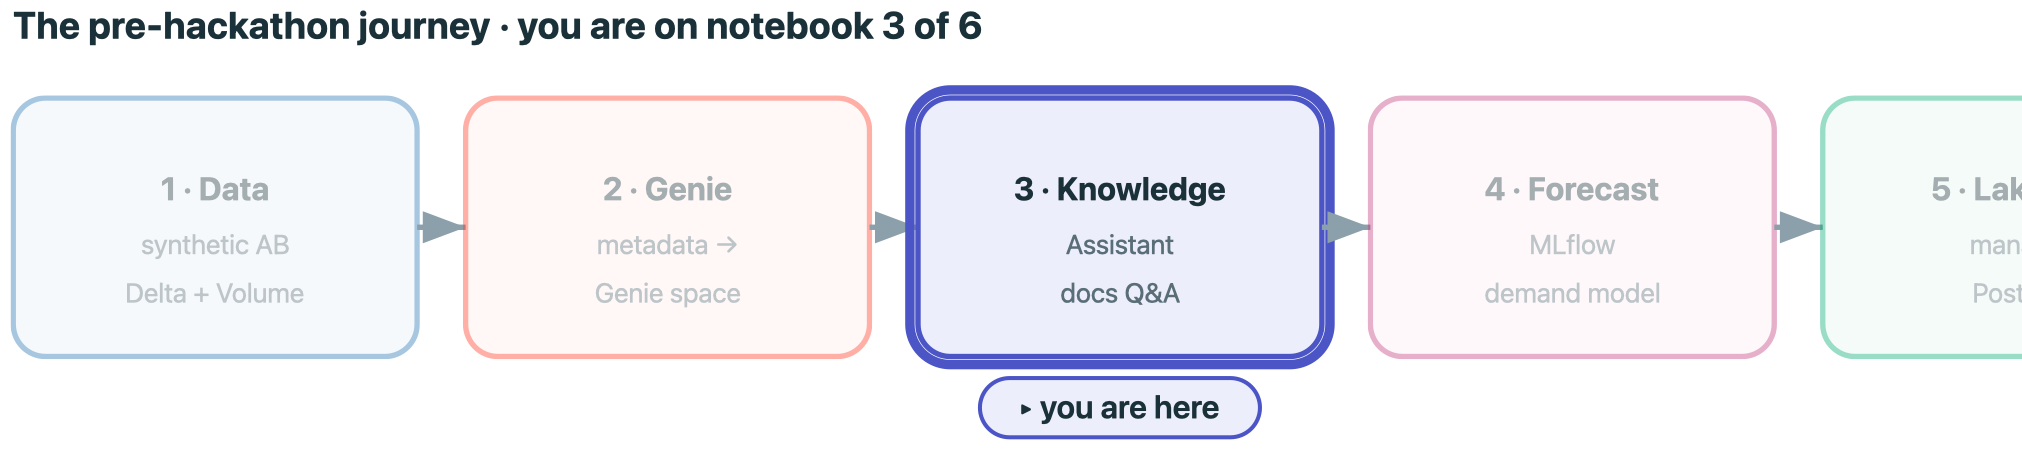

It needs only the **`knowledge_base` Volume from Notebook 1** — the PDFs you
generated there. The **app in Notebook 6** will call this assistant alongside
Genie, so keep the endpoint name it produces.

> **You won't create the endpoint from code here.** Agent Bricks builds and deploys
> the assistant from the **UI** (Step 2) — that's the one manual step. Everything
> else in this notebook just **confirms** the docs (Step 1) and **queries** the
> deployed endpoint (Step 4). The diagrams in Step 2 show what Databricks builds for
> you behind that one click.

### What is Agent Bricks?
**Agent Bricks** is Databricks' guided way to build production agents. The
**Knowledge Assistant** flavour is purpose-built for Q&A over unstructured docs:
you point it at a knowledge source (a **UC Volume** or a **Vector Search index**),
and Databricks handles the hard parts — **chunking, embedding, indexing, and
retrieval** — then deploys a **model serving endpoint** you can query from a
notebook, an app, or another agent. It's all governed by Unity Catalog.

### Structured + unstructured, one story
- **Genie** (Notebook 2) → *"What were West-region case volumes last quarter?"*
- **Knowledge Assistant** (here) → *"What's our on-time delivery policy, and how
  is 'on-time' defined?"*

Same data domain, same governance — two complementary agents. (An Agent Bricks
**Multi-Agent Supervisor** can even route between them; noted in the recap.)

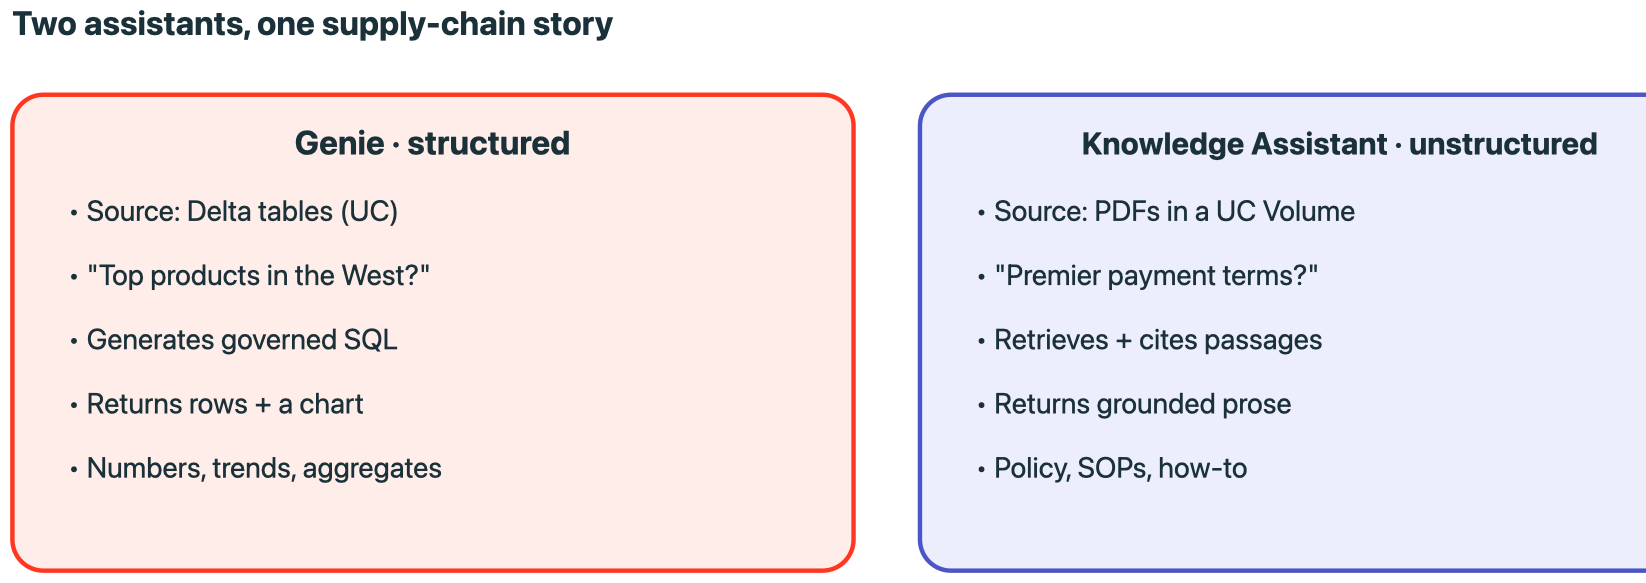

### What you'll do
1. **Confirm** the knowledge base (the Volume + PDFs from Notebook 1)
2. **Create** the Knowledge Assistant in Agent Bricks (a short UI walkthrough)
3. **Find** its serving endpoint
4. **Query** it programmatically — grounded answers with citations
5. Understand the **governance**, and how to wire it into the app

> **Prerequisites:** Notebook 1 completed (it created the `knowledge_base`
> Volume and the PDFs). An **FE-VM / serverless** workspace with **Agent Bricks**
> and **Vector Search** available. Same `catalog`/`schema` as Notebook 1.

## Step 0 · Upgrade the SDK

We query the deployed assistant with the **`databricks-openai`** client (the current,
non-deprecated way — it speaks the OpenAI **responses** API that Agent Bricks agents
use). Install it plus a recent `databricks-sdk`, once, at the top (`restartPython`
clears state, so run this **first**).

In [ ]:
%pip install --quiet --upgrade databricks-sdk databricks-openai
dbutils.library.restartPython()

## Step 1 · Confirm the knowledge base

Point at the **same** `catalog`/`schema` as Notebook 1 and confirm the Volume and
its PDFs are there. If it's empty, run **Notebook 1 · Step 5** first (that's where
the Volume and documents are created).

In [ ]:
# Create the widgets. Run this cell, set the values up top, then run the next cell.
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog (same as Notebook 1)")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (username appended — matches NB1)")

In [ ]:
# Now read the widgets and derive the per-user schema (same as Notebook 1).
import re
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{re.sub(r'[^a-z0-9]+', '_', _user.split('@')[0].lower()).strip('_')}"
VOLUME = "knowledge_base"
FQ = f"{CATALOG}.{SCHEMA}"
VOL_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"

files = dbutils.fs.ls(VOL_PATH)  # errors if the Volume is missing -> run Notebook 1 Step 5
pdfs = [f for f in files if f.name.lower().endswith(".pdf")]
for f in sorted(pdfs, key=lambda x: x.name):
    print(f"  {f.name:52s} {f.size / 1024:6.1f} KB")
assert pdfs, f"No PDFs in {VOL_PATH} — run Notebook 1 · Step 5 first."
print(f"\n{len(pdfs)} documents ready in {VOL_PATH}")

## Step 2 · Create the Knowledge Assistant (Agent Bricks) — the one manual step

Agent Bricks is a **guided, UI-first** experience: you fill in a short form and
Databricks builds and deploys the whole retrieval pipeline. There's **no code to
write** — here's the form you fill in:

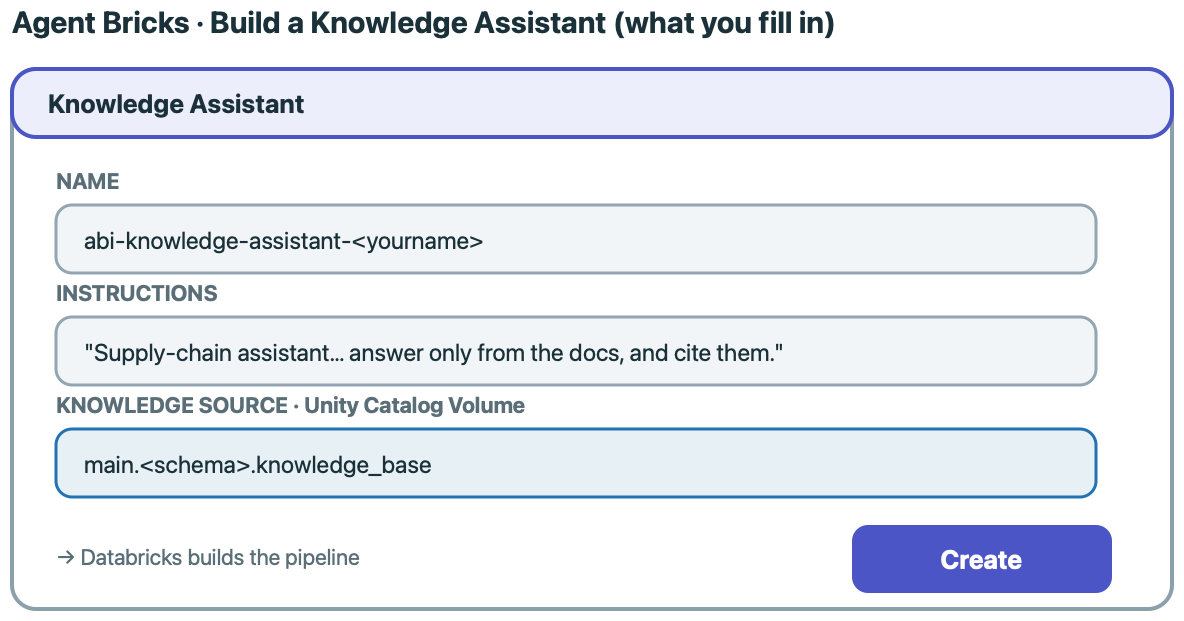

1. Left nav → **Agents** → **Agent Bricks** → **Knowledge Assistant** → **Build**.
2. **Name** it per-person so a shared workspace doesn't collide, e.g.
   `abi-knowledge-assistant-<yourname>`.
3. **Instructions** — steer tone and scope, e.g. *"You are a supply-chain operations
   assistant for an Anheuser-Busch beverage distribution business… answer only from
   the provided documents, and cite them. If the answer isn't in the docs, say so."*
4. **Add knowledge source** → **Unity Catalog Volume** → pick
   **`{catalog}.{schema}.knowledge_base`** (the Volume from Step 1).
5. **Create**, then wait a few minutes for it to deploy.

### What Databricks builds when you click Create

You don't write any of this — but it's worth knowing what's happening in the
backend, because it's a full **RAG (retrieval-augmented generation)** pipeline:

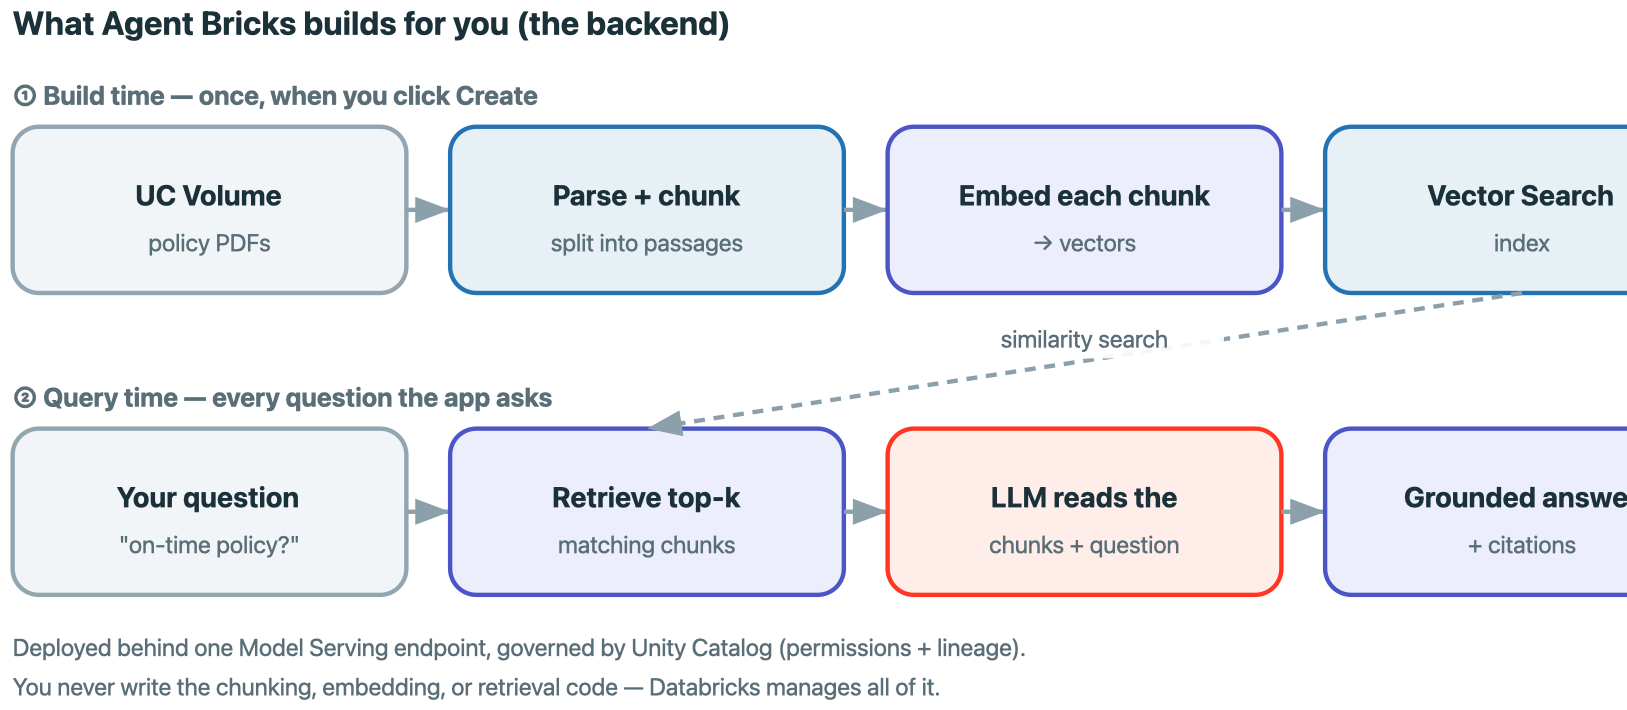

At **build time** it parses the PDFs, splits them into passages, embeds each one,
and stores the vectors in a **Vector Search index**. At **query time** it embeds
your question, retrieves the most similar passages, and has an **LLM** compose an
answer *from those passages* — with **citations**. All of it is wrapped in one
**Model Serving endpoint**, governed by Unity Catalog.

> **Why the UI?** Knowledge Assistant *creation* is driven from Agent Bricks today.
> Everything after — querying, evaluation, wiring into an app — is programmatic,
> which is what the rest of this notebook shows.

## Step 3 · Find your endpoint

Once the assistant finishes deploying, it appears as a **serving endpoint**. Run
this to list endpoints, then set the `endpoint_name` widget to the one Agent
Bricks created (its name matches the assistant, often prefixed like `ka-…` or
`agents_…`).

In [ ]:
from databricks.sdk import WorkspaceClient
w = WorkspaceClient()

print("Serving endpoints in this workspace:\n")
for e in w.serving_endpoints.list():
    print(f"  {e.name}")

dbutils.widgets.text("endpoint_name", "", "Knowledge Assistant serving-endpoint name")
ENDPOINT = dbutils.widgets.get("endpoint_name").strip()
print(f"\nSelected endpoint: {ENDPOINT or '(set the endpoint_name widget above)'}")

## Step 4 · Query the assistant — grounded answers with citations

**Agent Bricks agents (including the Knowledge Assistant) are served as
`ResponsesAgent`s** — they speak the OpenAI **responses** schema, i.e. they want
`{"input": [{"role": "user", "content": "…"}]}`, **not** a `messages` field. So we
query with the current **`databricks-openai`** client's **responses** API
(`client.responses.create(model=ENDPOINT, input=[…])`). Two things this rules out:
`chat.completions` (raises *"Missing required arguments ('messages' and 'model')"*)
and the old `get_open_ai_client()` (now deprecated). The retriever pulls the relevant
chunks from your PDFs and answers from them; the questions map to Notebook 1's docs.

> `ask_ka` falls back to the raw SDK **`w.serving_endpoints.query(name=ENDPOINT,
> input=…)`** (which sends the same `{"input": […]}` body) if `databricks-openai`
> isn't installed — so it works either way.

In [ ]:
# Re-read the widget here so you can set it after Step 3's listing, then run this cell.
ENDPOINT = dbutils.widgets.get("endpoint_name").strip()
assert ENDPOINT, "Set the endpoint_name widget (Step 3) to your assistant's endpoint."

def _answer_text(resp):
    """Pull the text out of a responses result (object or dict), across shapes."""
    txt = getattr(resp, "output_text", None)
    if txt:
        return txt
    # Walk .output (or a dict's "output") → items → content → text.
    output = getattr(resp, "output", None) or (resp.get("output") if isinstance(resp, dict) else None)
    parts = []
    for item in (output or []):
        content = getattr(item, "content", None) or (item.get("content") if isinstance(item, dict) else None)
        for c in (content or []):
            t = getattr(c, "text", None) or (c.get("text") if isinstance(c, dict) else None)
            if t:
                parts.append(t)
    return "\n".join(parts) if parts else str(resp)

def ask_ka(question, history=None):
    """Ask the Knowledge Assistant (a ResponsesAgent). Returns (answer, updated_history).

    Uses the databricks-openai client's responses API; falls back to the raw SDK
    query(input=...) — both send the {"input": [...]} schema the endpoint requires."""
    messages = (history or []) + [{"role": "user", "content": question}]
    try:
        from databricks_openai import DatabricksOpenAI
        resp = DatabricksOpenAI().responses.create(model=ENDPOINT, input=messages)
    except Exception:
        resp = w.serving_endpoints.query(name=ENDPOINT, input=messages)  # sends {"input": [...]}
    answer = _answer_text(resp)
    return answer, messages + [{"role": "assistant", "content": answer}]

q1 = "What is the credit limit for a Premier distributor, and what are the standard payment terms?"
ans, hist = ask_ka(q1)
print("Q:", q1, "\n\nA:", ans)

In [ ]:
# One more grounded question, then a multi-turn follow-up (the assistant keeps
# context across the conversation — note we pass `hist` back in).
q2 = "How is on-time delivery defined, and which distribution center serves the West region?"
ans, hist = ask_ka(q2)
print("Q:", q2, "\n\nA:", ans, "\n")

follow_up = "And within how many days must a damaged-goods return be reported?"
a3, hist = ask_ka(follow_up, history=hist)
print("Q:", follow_up, "\n\nA:", a3)

> **Other ways to call it.** `ask_ka` already handles the `databricks-openai`
> responses path and the raw `serving_endpoints.query(input=…)` fallback. You can
> also hit the REST endpoint directly at
> `POST {host}/serving-endpoints/{ENDPOINT}/invocations` with a bearer token and a
> responses-style `{"input": [{"role": "user", "content": "…"}]}` body.

## Step 5 · Governance, and wiring it into the app

The Knowledge Assistant runs **inside** Unity Catalog governance:
- **Grounded + cited.** Answers come from *your* documents, with citations — so
  you can trace every claim back to a source PDF (curbs hallucination).
- **Permissions.** The endpoint runs as an identity that must have access to the
  Volume; a caller (a user or an app's **service principal**) must have
  **`CAN_QUERY`** on the serving endpoint. Same model as any Databricks endpoint.
- **Refresh.** Drop new PDFs into the `knowledge_base` Volume and re-sync / re-index
  from Agent Bricks to keep answers current — the Volume is the single source.
- **Lineage & audit.** The endpoint, the vector index, and the Volume are all UC
  assets, so usage and lineage are captured.

**Wire it into the Databricks App (Notebook 6).** The app adds the assistant's
serving endpoint as a **resource** (the app SP gets `CAN_QUERY`) and a *"Docs"*
tab that calls `ask_ka(...)` exactly like above — so one app answers both **data**
questions (Genie) and **policy** questions (Knowledge Assistant). Note the
endpoint name from Step 3; you'll set it on the app.

## ✅ Recap

You built a governed **Knowledge Assistant** over the documents from Notebook 1:

- **Source:** the `knowledge_base` **UC Volume** of supply-chain PDFs.
- **Agent Bricks** chunked, embedded, indexed (Vector Search) and deployed it as a
  **serving endpoint** — no pipeline code to maintain.
- You queried it programmatically for **grounded, cited** answers, single- and
  multi-turn — the same call an app makes.
- It's **complementary to Genie**: structured Q&A (Genie) + document Q&A
  (Knowledge Assistant), one governance model.

**Next → Notebook 4:** a **demand-forecasting** model with MLflow — the third AI
asset the app will surface. (You can also later combine Genie + this assistant
behind an Agent Bricks **Multi-Agent Supervisor** that routes each question to the
right specialist.)